# 線性代數中的投影概念

在線性代數中，**投影（projection）** 是把一個向量按照某種規則對應到某個方向、直線、平面或子空間上的操作。直觀地說，投影可以理解為取得一個向量在目標空間上的「影子」或「分量」。

投影的核心問題是：給定一個向量 $v$，以及一個目標空間 $W$，如何在 $W$ 中找到一個向量 $p$ 來代表 $v$ 在 $W$ 上的部分？

一般可以寫成：

$$
v = p + e
$$

其中 $p$ 是投影結果，$e=v-p$ 是剩下的誤差向量。不同類型的投影，差異主要在於誤差向量 $e$ 的方向如何被指定。

本 notebook 會依序介紹兩種常見觀念：

1. **正交投影（orthogonal projection）**：誤差向量垂直於目標空間。
2. **斜投影（oblique projection）**：誤差向量沿著指定方向或指定子空間。

兩者都屬於投影概念，但幾何意義不同。正交投影常用於最小距離問題；斜投影則強調沿著某個指定方向進行分解。

## 1. 正交投影：投影到一個向量所張成的方向

最常見的投影是**正交投影（orthogonal projection）**。

假設有一個向量 $v$，我們想把它投影到另一個非零向量 $u$ 所張成的直線上，也就是投影到 $\mathrm{span}(u)$。

投影結果記為：

$$
\mathrm{proj}_u(v)
$$

公式是：

$$
\mathrm{proj}_u(v)=\frac{v\cdot u}{u\cdot u}u
$$

其中 $v\cdot u$ 是內積，$u\cdot u=\|u\|^2$。

這個公式的作用是取出 $v$ 在 $u$ 方向上的分量。

## 2. 正交投影的幾何意義

$\mathrm{proj}_u(v)$ 是 $v$ 在 $u$ 方向上的分量。

原向量 $v$ 可以拆成兩部分：

$$
v = \mathrm{proj}_u(v) + \left(v-\mathrm{proj}_u(v)\right)
$$

其中：

- $\mathrm{proj}_u(v)$ 是平行於 $u$ 的部分。
- $v-\mathrm{proj}_u(v)$ 是垂直於 $u$ 的部分。

因此，正交投影可以被視為把一個向量分解成「平行於目標方向的分量」與「垂直於目標方向的誤差分量」。

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def projection(v, u):
    """計算向量 v 在向量 u 方向上的正交投影。"""
    v = np.array(v, dtype=float)
    u = np.array(u, dtype=float)
    if np.allclose(u, 0):
        raise ValueError("u 不能是零向量")
    return (np.dot(v, u) / np.dot(u, u)) * u

## 3. 正交投影例子：投影到 x 軸

令

$$
v=\begin{bmatrix}3\\4\end{bmatrix},\quad
u=\begin{bmatrix}1\\0\end{bmatrix}
$$

$u$ 代表 $x$ 軸方向。把 $v$ 正交投影到 $x$ 軸上：

$$
\mathrm{proj}_u(v)
=
\frac{
\begin{bmatrix}3\\4\end{bmatrix}\cdot\begin{bmatrix}1\\0\end{bmatrix}
}{
\begin{bmatrix}1\\0\end{bmatrix}\cdot\begin{bmatrix}1\\0\end{bmatrix}
}
\begin{bmatrix}1\\0\end{bmatrix}
=
\begin{bmatrix}3\\0\end{bmatrix}
$$

也就是把點 $(3,4)$ 垂直落到 $x$ 軸，得到 $(3,0)$。

In [3]:
v = np.array([3, 4])
u = np.array([1, 0])
p = projection(v, u)
e = v - p

print("v =", v)
print("u =", u)
print("proj_u(v) =", p)
print("v - proj_u(v) =", e)
print("誤差向量與 u 的內積 =", np.dot(e, u))

v = [3 4]
u = [1 0]
proj_u(v) = [3. 0.]
v - proj_u(v) = [0. 4.]
誤差向量與 u 的內積 = 0.0


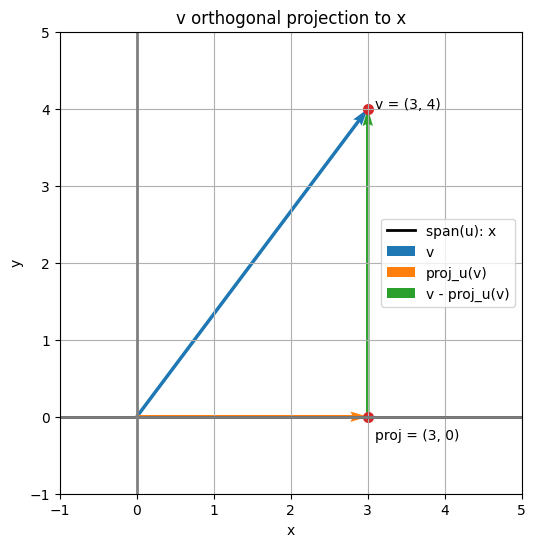

In [4]:
plt.figure(figsize=(7, 6))

line_width = 2

# x 軸，也就是 span(u)
x = np.linspace(-1, 5, 100)
plt.plot(
    x,
    np.zeros_like(x),
    color="black",
    linewidth=line_width,
    label="span(u): x"
)

# 畫出 v、投影 p、誤差 e
plt.quiver(
    0, 0, v[0], v[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="tab:blue",
    linewidth=line_width,
    label="v"
)

plt.quiver(
    0, 0, p[0], p[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="tab:orange",
    linewidth=line_width,
    label="proj_u(v)"
)

plt.quiver(
    p[0], p[1], e[0], e[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="tab:green",
    linewidth=line_width,
    label="v - proj_u(v)"
)

# 標示點
plt.scatter(
    [v[0], p[0]],
    [v[1], p[1]],
    color="tab:red",
    linewidths=line_width
)

plt.text(v[0] + 0.1, v[1], "v = (3, 4)")
plt.text(p[0] + 0.1, p[1] - 0.3, "proj = (3, 0)")

plt.axhline(0, color="gray", linewidth=line_width)
plt.axvline(0, color="gray", linewidth=line_width)

plt.xlim(-1, 5)
plt.ylim(-1, 5)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True)
plt.legend()
plt.title("v orthogonal projection to x")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## 4. 正交投影到一般方向

投影不一定只能投影到 $x$ 軸，也可以投影到任意非零向量 $u$ 所張成的直線。

以下例子令：

$$
v=\begin{bmatrix}3\\4\end{bmatrix},\quad
u=\begin{bmatrix}2\\1\end{bmatrix}
$$

我們計算 $v$ 在 $u$ 方向上的正交投影。此時投影結果會落在 $\mathrm{span}(u)$ 上，而誤差向量 $v-\mathrm{proj}_u(v)$ 會垂直於 $u$。

In [5]:
v = np.array([3, 4])
u = np.array([2, 1])
p = projection(v, u)
e = v - p

print("v =", v)
print("u =", u)
print("proj_u(v) =", p)
print("v - proj_u(v) =", e)
print("誤差向量與 u 的內積 =", np.dot(e, u))

v = [3 4]
u = [2 1]
proj_u(v) = [4. 2.]
v - proj_u(v) = [-1.  2.]
誤差向量與 u 的內積 = 0.0


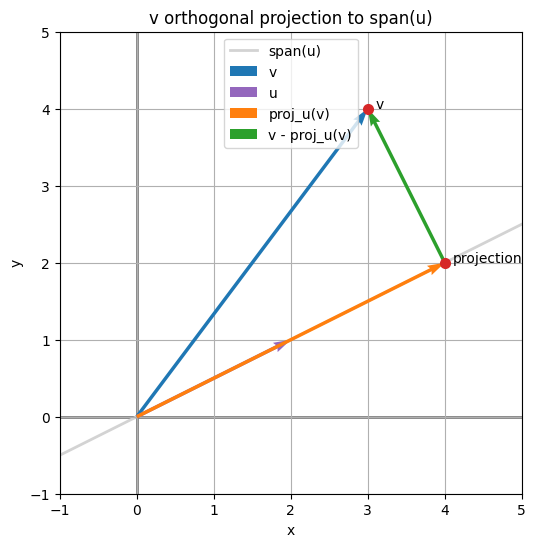

In [6]:
plt.figure(figsize=(7, 6))

line_width = 2

# span(u) 的直線：使用淺色作為背景參考線
t = np.linspace(-1, 3, 100)
line = np.outer(t, u)

plt.plot(
    line[:, 0],
    line[:, 1],
    color="lightgray",
    linewidth=line_width,
    label="span(u)",
    zorder=1
)

# 畫出 v、u 方向、投影 p、誤差 e
plt.quiver(
    0, 0, v[0], v[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="tab:blue",
    linewidth=line_width,
    label="v",
    zorder=3
)

plt.quiver(
    0, 0, u[0], u[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="tab:purple",
    linewidth=line_width,
    label="u",
    zorder=3
)

plt.quiver(
    0, 0, p[0], p[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="tab:orange",
    linewidth=line_width,
    label="proj_u(v)",
    zorder=4
)

plt.quiver(
    p[0], p[1], e[0], e[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="tab:green",
    linewidth=line_width,
    label="v - proj_u(v)",
    zorder=4
)

plt.scatter(
    [v[0], p[0]],
    [v[1], p[1]],
    color="tab:red",
    linewidths=line_width,
    zorder=5
)

plt.text(v[0] + 0.1, v[1], "v", zorder=6)
plt.text(p[0] + 0.1, p[1], "projection", zorder=6)

plt.axhline(0, color="gray", linewidth=line_width, zorder=0)
plt.axvline(0, color="gray", linewidth=line_width, zorder=0)

plt.xlim(-1, 5)
plt.ylim(-1, 5)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True)
plt.legend()
plt.title("v orthogonal projection to span(u)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## 5. 正交投影到子空間

更一般地，若要把向量 $v$ 投影到一個子空間 $W$，正交投影 $p$ 會滿足兩個條件：

$$
p \in W
$$

而且

$$
v-p \perp W
$$

意思是：投影結果 $p$ 在目標子空間裡，而誤差向量 $v-p$ 垂直於該子空間。

這也是投影在資料分析、最小平方法、機器學習中很重要的原因。當一個向量無法完全落在某個子空間中時，正交投影會給出該子空間中距離原向量最近的向量。

## 6. 正交投影重點整理

到目前為止，正交投影的重點如下：

1. 正交投影是把向量映到某個方向、直線、平面或子空間上的操作。
2. 投影結果會落在目標空間中。
3. 誤差向量會垂直於目標空間。
4. 向量投影公式為：

$$
\mathrm{proj}_u(v)=\frac{v\cdot u}{u\cdot u}u
$$

5. 正交投影可用來找出目標子空間中最接近原向量的近似。

## 7. 斜投影：沿著指定方向投影

除了正交投影之外，線性代數中也有**斜投影（oblique projection）**。

正交投影要求誤差向量與目標空間垂直；斜投影則不要求垂直，而是指定誤差向量沿著另一個方向或子空間。

仍然寫成：

$$
v = p + e
$$

其中：

$$
p \in W
$$

而

$$
e \in U
$$

這裡 $W$ 是投影目標空間，$U$ 是指定的投影方向空間。

因此，正交投影可以理解為「垂直落到目標空間」，斜投影則是「沿著指定斜方向落到目標空間」。兩者都會得到目標空間中的投影結果，但誤差向量的方向條件不同。

### 例子：沿著斜方向投影到 x 軸

令

$$
v=\begin{bmatrix}3\\4\end{bmatrix}
$$

我們仍然把 $v$ 投影到 $x$ 軸上，但這次不是垂直投影，而是沿著方向

$$
d=\begin{bmatrix}1\\1\end{bmatrix}
$$

進行斜投影。

投影點在 $x$ 軸上，所以可設為：

$$
p=\begin{bmatrix}a\\0\end{bmatrix}
$$

而斜投影要求 $v-p$ 平行於方向 $d$，所以：

$$
v-p=td
$$

代入後可得：

$$
\begin{bmatrix}3\\4\end{bmatrix}
-
\begin{bmatrix}a\\0\end{bmatrix}
=
t
\begin{bmatrix}1\\1\end{bmatrix}
$$

因此：

$$
\begin{bmatrix}3-a\\4\end{bmatrix}
=
\begin{bmatrix}t\\t\end{bmatrix}
$$

由第二個分量得 $t=4$，再由第一個分量得 $3-a=4$，所以 $a=-1$。

因此斜投影結果為：

$$
p=\begin{bmatrix}-1\\0\end{bmatrix}
$$

這和正交投影到 $x$ 軸的結果 $\begin{bmatrix}3\\0\end{bmatrix}$ 不同。

In [7]:
v = np.array([3, 4])
d = np.array([1, 1])

# 投影到 x 軸，因此投影點可寫成 p = [a, 0]
# 斜投影要求 v - p 平行於 d，也就是 v - p = t d
t = v[1] / d[1]
a = v[0] - t * d[0]

p_oblique = np.array([a, 0])
e_oblique = v - p_oblique

print("v =", v)
print("投影方向 d =", d)
print("斜投影 p =", p_oblique)
print("誤差向量 v - p =", e_oblique)
print("誤差向量與 d 的比例 =", e_oblique / d)

v = [3 4]
投影方向 d = [1 1]
斜投影 p = [-1.  0.]
誤差向量 v - p = [4. 4.]
誤差向量與 d 的比例 = [4. 4.]


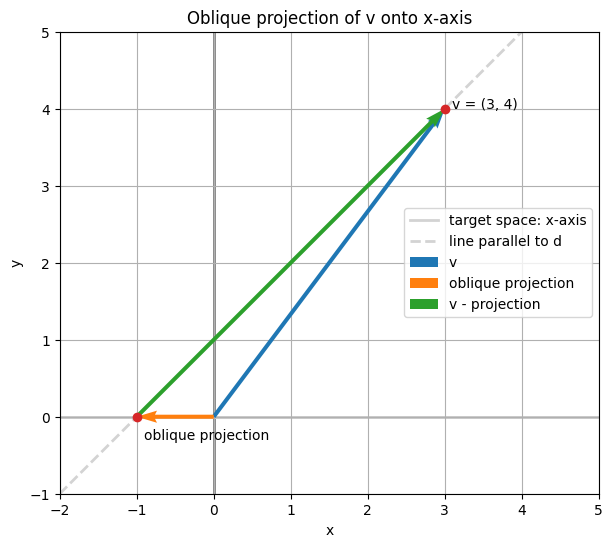

In [8]:
plt.figure(figsize=(7, 6))

line_width = 2

# 目標空間：x 軸
x = np.linspace(-2, 5, 100)
plt.plot(
    x,
    np.zeros_like(x),
    color="lightgray",
    linewidth=line_width,
    label="target space: x-axis",
    zorder=1
)

# 經過投影點，且平行於投影方向 d 的參考線
s = np.linspace(-1, 5, 100)
direction_line = p_oblique + np.outer(s, d)
plt.plot(
    direction_line[:, 0],
    direction_line[:, 1],
    color="lightgray",
    linestyle="--",
    linewidth=line_width,
    label="line parallel to d",
    zorder=1
)

# 原向量 v
plt.quiver(
    0, 0, v[0], v[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="tab:blue",
    linewidth=line_width,
    label="v",
    zorder=4
)

# 斜投影 p
plt.quiver(
    0, 0, p_oblique[0], p_oblique[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="tab:orange",
    linewidth=line_width,
    label="oblique projection",
    zorder=5
)

# 誤差向量 v - p，方向與 d 平行
plt.quiver(
    p_oblique[0], p_oblique[1],
    e_oblique[0], e_oblique[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="tab:green",
    linewidth=line_width,
    label="v - projection",
    zorder=5
)

plt.scatter(
    [v[0], p_oblique[0]],
    [v[1], p_oblique[1]],
    color="tab:red",
    zorder=6
)

plt.text(v[0] + 0.1, v[1], "v = (3, 4)", zorder=7)
plt.text(p_oblique[0] + 0.1, p_oblique[1] - 0.3, "oblique projection", zorder=7)

plt.axhline(0, color="gray", linewidth=line_width, zorder=0)
plt.axvline(0, color="gray", linewidth=line_width, zorder=0)

plt.xlim(-2, 5)
plt.ylim(-1, 5)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True)
plt.legend()
plt.title("Oblique projection of v onto x-axis")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## 8. 投影概念總結

投影的基本形式都是：

$$
v = p + e
$$

其中 $p$ 是投影到目標空間後的結果，$e$ 是剩餘的誤差向量。不同投影方式的差異，主要在於如何限制 $e$ 的方向。

| 類型 | 投影目標 | 誤差向量方向 | 幾何意義 |
|---|---|---|---|
| 正交投影 | 目標子空間 | 垂直於目標子空間 | 找到目標空間中距離原向量最近的點 |
| 斜投影 | 目標子空間 | 沿著指定方向或指定子空間 | 沿著指定方向把向量分解到目標空間 |

因此，投影不是單一公式而已，而是一種向量分解觀念。正交投影最常見，因為它和內積、距離最小化、最小平方法有直接關係；斜投影則展示了更一般的投影思維：投影結果落在目標空間中，但誤差方向可以由問題條件指定。